# This project analyzes the Sample Superstore dataset to identify the impact of discounting on profitability. Our analysis identified a 'Profit Cliff' at the 20% discount threshold, where profitability drops significantly. We recommend a shift toward value based pricing and category specific discount caps.

In [41]:
import numpy as np
import pandas as pd
from matplotlib  import pyplot as plt
import seaborn as sns
import sklearn as sk

In [136]:
sns.set_style("whitegrid")

In [42]:
df = pd.read_csv(r"C:\Users\KPK\data\SampleSuperstore.csv")

# Data Cleaning & Overview

**First five rows of dataset**

In [43]:
df.head(5)

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


**Last five rows of dataset**

In [44]:
df.tail(5)

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
9989,Second Class,Consumer,United States,Miami,Florida,33180,South,Furniture,Furnishings,25.248,3,0.2,4.1028
9990,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Furniture,Furnishings,91.960,2,0.0,15.6332
9991,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Technology,Phones,258.576,2,0.2,19.3932
9992,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Office Supplies,Paper,29.600,4,0.0,13.3200
9993,Second Class,Consumer,United States,Westminster,California,92683,West,Office Supplies,Appliances,243.160,2,0.0,72.9480


**Columns of the Dataset**

In [45]:
pd.Series(df.columns, name = "Columns")

0        Ship Mode
1          Segment
2          Country
3             City
4            State
5      Postal Code
6           Region
7         Category
8     Sub-Category
9            Sales
10        Quantity
11        Discount
12          Profit
Name: Columns, dtype: object

**information of the dataset**

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB


**Null Values Checking**

In [47]:
df.isnull().sum()

Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

**Duplicate Values Checking**

In [48]:
df[df.duplicated(keep=False)]

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
568,Standard Class,Corporate,United States,Seattle,Washington,98105,West,Office Supplies,Paper,19.440,3,0.0,9.3312
591,Standard Class,Consumer,United States,Salem,Oregon,97301,West,Office Supplies,Paper,10.368,2,0.2,3.6288
935,Standard Class,Home Office,United States,Philadelphia,Pennsylvania,19120,East,Office Supplies,Paper,15.552,3,0.2,5.4432
950,Standard Class,Home Office,United States,Philadelphia,Pennsylvania,19120,East,Office Supplies,Paper,15.552,3,0.2,5.4432
1186,Standard Class,Corporate,United States,Seattle,Washington,98103,West,Office Supplies,Paper,25.920,4,0.0,12.4416
1479,Standard Class,Consumer,United States,San Francisco,California,94122,West,Office Supplies,Paper,25.920,4,0.0,12.4416
2803,Standard Class,Consumer,United States,San Francisco,California,94122,West,Office Supplies,Paper,12.840,3,0.0,5.7780
2807,Second Class,Consumer,United States,Seattle,Washington,98115,West,Office Supplies,Paper,12.960,2,0.0,6.2208
2836,Standard Class,Consumer,United States,Los Angeles,California,90036,West,Office Supplies,Paper,19.440,3,0.0,9.3312
3127,Standard Class,Consumer,United States,New York City,New York,10011,East,Office Supplies,Paper,49.120,4,0.0,23.0864


In [49]:
df.drop_duplicates(keep="first", inplace=True)

**checking for negative values**

In [50]:
print(f"Number of rows with negative sales: {df[df['Sales'] < 0].shape[0]}")

Number of rows with negative sales: 0


**Summery of Dataset**

In [51]:
df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9977.000000,9977.000000,9977.000000,9977.000000,9977.00000
mean,55154.964117,230.148902,3.790719,0.156278,28.69013
std,32058.266816,623.721409,2.226657,0.206455,234.45784
min,1040.000000,0.444000,1.000000,0.000000,-6599.97800
25%,23223.000000,17.300000,2.000000,0.000000,1.72620
50%,55901.000000,54.816000,3.000000,0.200000,8.67100
75%,90008.000000,209.970000,5.000000,0.200000,29.37200
max,99301.000000,22638.480000,14.000000,0.800000,8399.97600


**Total Number Of Rows and Columns Of Dataset**

In [52]:
print(f"""
Number of Rows = {df.shape[0]}
Number of Columbs = {df.shape[1]}
""")


Number of Rows = 9977
Number of Columbs = 13



**Number of Unique Values Per Column**

In [53]:
df.nunique()

Ship Mode          4
Segment            3
Country            1
City             531
State             49
Postal Code      631
Region             4
Category           3
Sub-Category      17
Sales           5825
Quantity          14
Discount          12
Profit          7287
dtype: int64

**Types Of Ship Modes**

In [54]:
unique_modes = df["Ship Mode"].unique()
pd.Series(unique_modes, name="Ship Mode Types")

0      Second Class
1    Standard Class
2       First Class
3          Same Day
Name: Ship Mode Types, dtype: object

**Number Of Occurence Of Each Ship Mode**

In [55]:
print(f"""
Number of Same Day Shipments = {(df["Ship Mode"]== "Same Day").sum()}
Number of First Class Shipments = {(df["Ship Mode"]== "First Class").sum()}
Number of Second Class Shipments = {(df["Ship Mode"]== "Second Class").sum()}
Number of Standard Class Shipments = {(df["Ship Mode"]== "Standard Class").sum()}
""")


Number of Same Day Shipments = 542
Number of First Class Shipments = 1537
Number of Second Class Shipments = 1943
Number of Standard Class Shipments = 5955



**Unique Segments in the Dataset**

In [56]:
unique_segments = df["Segment"].unique()
print(f"Number of Unique Catagories = {df["Segment"].nunique()}")
print(pd.Series(unique_segments, name="Unique Segments"))

Number of Unique Catagories = 3
0       Consumer
1      Corporate
2    Home Office
Name: Unique Segments, dtype: object


**Unique Countries in Dataset**

In [57]:
unique_countries = df["Country"].unique()
print(f"Number of Unique Countries = {df["Country"].nunique()}")
pd.Series(unique_countries, name="Unique Countries")

Number of Unique Countries = 1


0    United States
Name: Unique Countries, dtype: object

**Unique States in Dataset**

In [58]:
unique_States = df["State"].unique()
print(f"Number of Unique States = {df["State"].nunique()}")
pd.Series(unique_States, name="Unique States")

Number of Unique States = 49


0                 Kentucky
1               California
2                  Florida
3           North Carolina
4               Washington
5                    Texas
6                Wisconsin
7                     Utah
8                 Nebraska
9             Pennsylvania
10                Illinois
11               Minnesota
12                Michigan
13                Delaware
14                 Indiana
15                New York
16                 Arizona
17                Virginia
18               Tennessee
19                 Alabama
20          South Carolina
21                  Oregon
22                Colorado
23                    Iowa
24                    Ohio
25                Missouri
26                Oklahoma
27              New Mexico
28               Louisiana
29             Connecticut
30              New Jersey
31           Massachusetts
32                 Georgia
33                  Nevada
34            Rhode Island
35             Mississippi
36                Arkansas
3

**Unique Cities in Dataset**

In [59]:
unique_Cities = df["City"].unique()
pd.set_option('display.max_rows', None)
print(f"Number of Unique Cities = {df["City"].nunique()}")
print(pd.Series(unique_Cities, name="Unique Cities"))


Number of Unique Cities = 531
0              Henderson
1            Los Angeles
2        Fort Lauderdale
3                Concord
4                Seattle
5             Fort Worth
6                Madison
7            West Jordan
8          San Francisco
9                Fremont
10          Philadelphia
11                  Orem
12               Houston
13            Richardson
14            Naperville
15             Melbourne
16                 Eagan
17              Westland
18                 Dover
19            New Albany
20         New York City
21                  Troy
22               Chicago
23               Gilbert
24           Springfield
25               Jackson
26               Memphis
27               Decatur
28                Durham
29              Columbia
30             Rochester
31           Minneapolis
32              Portland
33            Saint Paul
34                Aurora
35             Charlotte
36           Orland Park
37             Urbandale
38              Colu

**Unique Catagories in Dataset**

In [60]:
unique_catagories = df["Category"].unique()
print(f"Number of Unique Catagories = {df["Category"].nunique()}")
print(pd.Series(unique_catagories, name="Unique Catagories"))

Number of Unique Catagories = 3
0          Furniture
1    Office Supplies
2         Technology
Name: Unique Catagories, dtype: object


**Unique Subcatagory in Dataset**

In [61]:
unique_sub_catagories = df["Sub-Category"].unique()
print(f"Number of Unique Catagories = {df["Sub-Category"].nunique()}")
print(pd.Series(unique_sub_catagories, name="Unique Sub-Catagories"))

Number of Unique Catagories = 17
0       Bookcases
1          Chairs
2          Labels
3          Tables
4         Storage
5     Furnishings
6             Art
7          Phones
8         Binders
9      Appliances
10          Paper
11    Accessories
12      Envelopes
13      Fasteners
14       Supplies
15       Machines
16        Copiers
Name: Unique Sub-Catagories, dtype: object


**Sales by Each Category in different ship mode and country wise**

In [62]:
sales_by_category = df.groupby(["Category",'Ship Mode', 'Country'])[["Sales", "Quantity", "Discount", "Profit"]].sum()

In [63]:
sales_by_category

Sales  Quantity  Discount  \
Category        Ship Mode      Country                                          
Furniture       First Class    United States  110730.5229      1238     58.87   
                Same Day       United States   39148.7790       453     22.15   
                Second Class   United States  156289.0244      1569     73.65   
                Standard Class United States  435137.9870      4760    213.92   
Office Supplies First Class    United States  101284.3570      3369    153.80   
                Same Day       United States   29049.0810      1143     46.80   
                Second Class   United States  160666.4790      4475    148.00   
                Standard Class United States  427735.3270     13874    597.60   
Technology      First Class    United States  139365.5910      1083     40.30   
                Same Day       United States   60123.8650       360     13.80   
                Second Class   United States  142221.5420      1374     47.70   
                Standard Class United States  494443.0350      4122    142.60   

                                                  Profit  
Category        Ship Mode      Country                    
Furniture       First Class    United States   3066.9474  
                Same Day       United States    797.3484  
                Second Class   United States   4226.2614  
                Standard Class United States  10331.2565  
Office Supplies First Class    United States  18384.1453  
                Same Day       United States   6403.6472  
                Second Class   United States  27068.1838  
                Standard Class United States  70508.6845  
Technology      First Class    United States  27502.5634  
                Same Day       United States   8670.8913  
                Second Class   United States  26152.2064  
                Standard Class United States  83129.2870

**Stacked Bar Plot where x axis = (categories, ship mode, country) , y axis = value range, color = (sales, Quantity, Discount, Profit)**

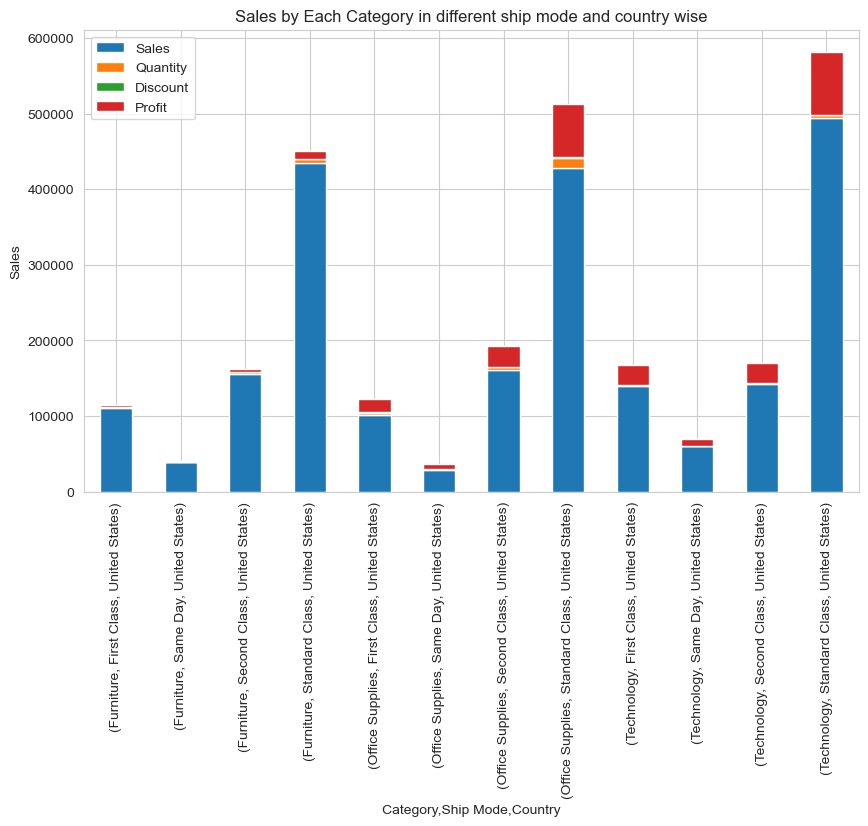

In [137]:
sales_by_category.plot(kind="bar", stacked=True, figsize=(10,6))
plt.title("Sales by Each Category in different ship mode and country wise")
plt.ylabel("Sales")
plt.show()

In [65]:
pivot_tb1 = sales_by_category.pivot_table(index="Category", columns="Ship Mode", values="Sales")

In [66]:
pivot_tb1

Ship Mode,First Class,Same Day,Second Class,Standard Class
Category,,,,
Furniture,110730.5229,39148.779,156289.0244,435137.987
Office Supplies,101284.3570,29049.081,160666.4790,427735.327
Technology,139365.5910,60123.865,142221.5420,494443.035


**Stacked Bar Plot where x axis = categories, y axis = sales , color = ship mode**

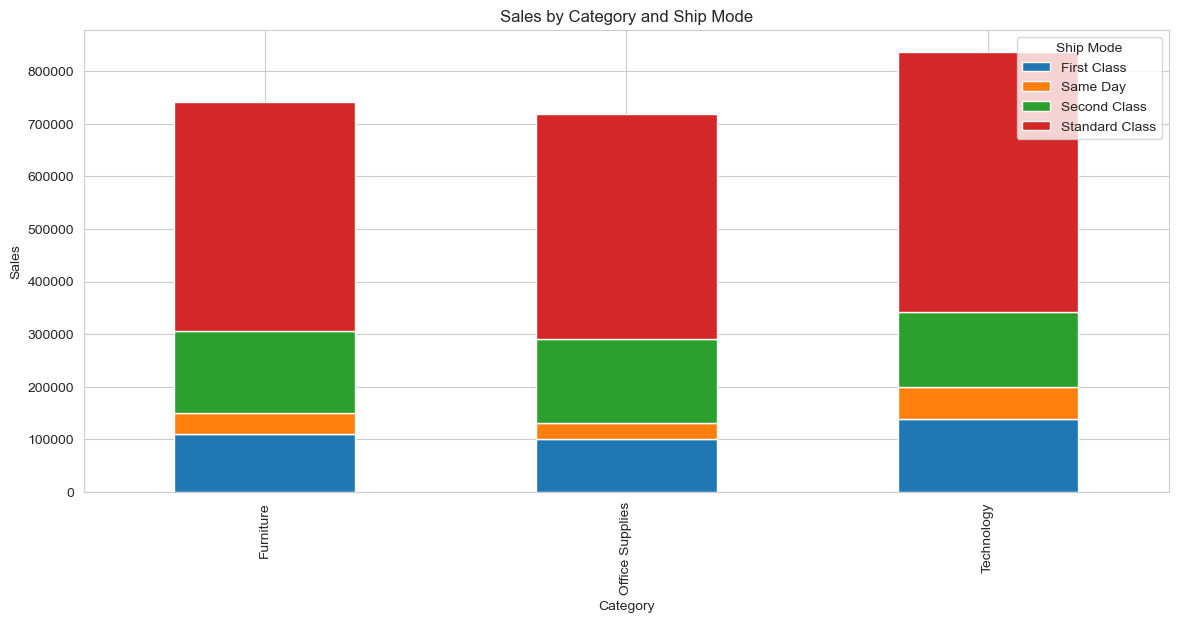

In [138]:
pivot_tb1.plot(kind="bar", stacked=True, figsize=(14,6))
plt.title("Sales by Category and Ship Mode")
plt.ylabel("Sales")
plt.show()

**Grouped Bar Plot where x axis = categories, y axis = sales , hue = ship mode**

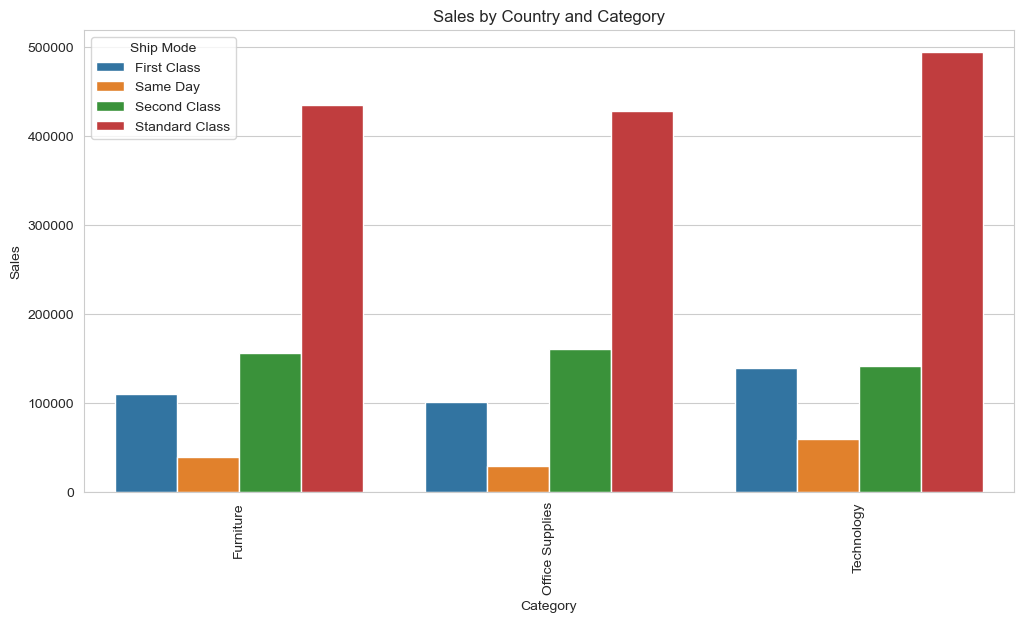

In [139]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=sales_by_category,
    x="Category", y="Sales", hue='Ship Mode'
)
plt.title("Sales by Country and Category")
plt.xticks(rotation=90)
plt.show()

# Statistical Correlation

**Non Numeric Columns**

In [69]:
numeric_columns= df.select_dtypes(include=["number"])

In [70]:
numeric_columns

,Postal Code,Sales,Quantity,Discount,Profit
0,42420,261.9600,2,0.00,41.9136
1,42420,731.9400,3,0.00,219.5820
2,90036,14.6200,2,0.00,6.8714
3,33311,957.5775,5,0.45,-383.0310
4,33311,22.3680,2,0.20,2.5164
5,90032,48.8600,7,0.00,14.1694
6,90032,7.2800,4,0.00,1.9656
7,90032,907.1520,6,0.20,90.7152
8,90032,18.5040,3,0.20,5.7825
9,90032,114.9000,5,0.00,34.4700


In [71]:
numeric_columns.drop(columns=["Postal Code"], inplace=True)

In [72]:
corr_matrix = numeric_columns.corr()

In [73]:
corr_matrix

,Sales,Quantity,Discount,Profit
Sales,1.000000,0.200722,-0.028311,0.479067
Quantity,0.200722,1.000000,0.008678,0.066211
Discount,-0.028311,0.008678,1.000000,-0.219662
Profit,0.479067,0.066211,-0.219662,1.000000


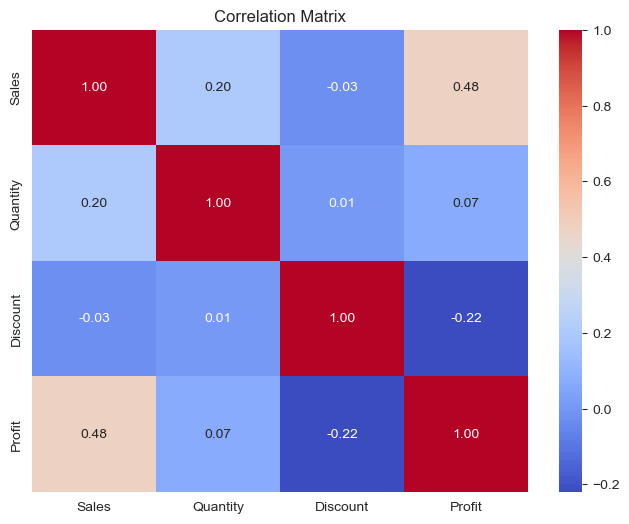

In [140]:
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [75]:
corr_bw_discount_profit = numeric_columns["Discount"].corr(numeric_columns["Profit"])

In [76]:
print(f"The Correlation between Discount and Profit is: {corr_bw_discount_profit:.4f}")

The Correlation between Discount and Profit is: -0.2197


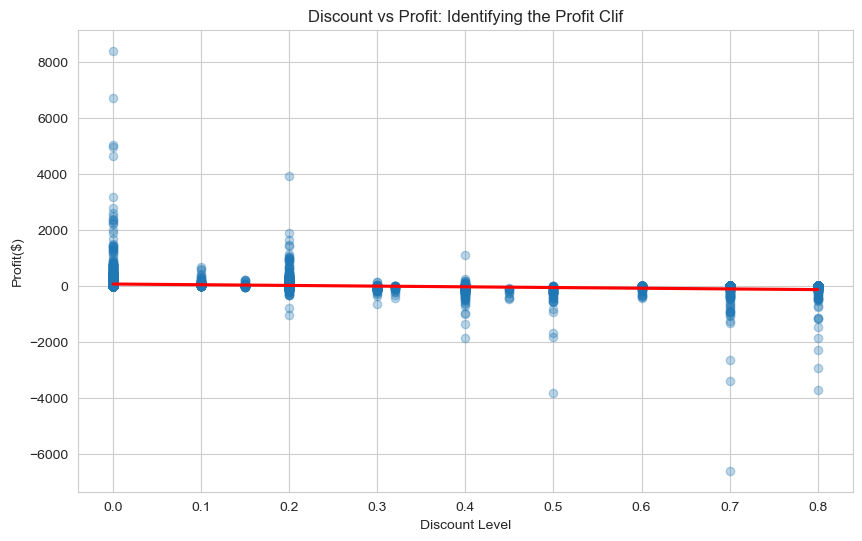

In [141]:
plt.figure(figsize=(10,6))
sns.regplot(data=numeric_columns, x="Discount", y="Profit", scatter_kws = {'alpha':0.3}, line_kws = {"color": "red"})
plt.title("Discount vs Profit: Identifying the Profit Clif")
plt.xlabel("Discount Level")
plt.ylabel("Profit($)")
plt.show()

### A strong negative correlation is observed, meaning higher discounts lead to lower profits. This occurs because price reductions directly shrink margins. Businesses should carefully optimize discount levels to avoid loss making sales

In [78]:
corr_bw_sales_quantity = numeric_columns["Sales"].corr(numeric_columns["Quantity"])

In [79]:
print(f"The Correlation between Sales and Quantity is: {corr_bw_sales_quantity:.4f}")

The Correlation between Sales and Quantity is: 0.2007


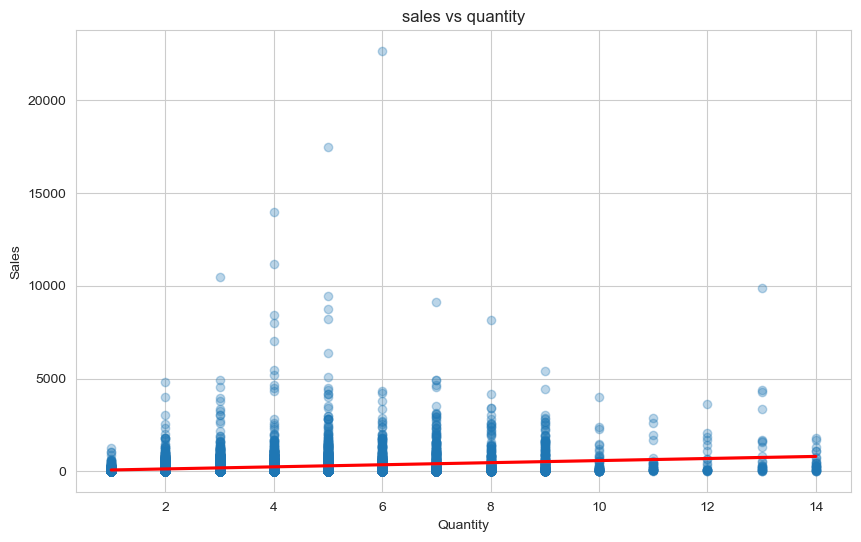

In [142]:
plt.figure(figsize=(10,6))
sns.regplot(data=numeric_columns, x="Quantity", y="Sales", scatter_kws = {'alpha':0.3}, line_kws = {"color": "red"})
plt.title("sales vs quantity")
plt.xlabel("Quantity")
plt.ylabel("Sales")
plt.show()

In [81]:
corr_bw_sales_discount = numeric_columns["Sales"].corr(numeric_columns["Discount"])

In [82]:
print(f"The Correlation between Sales and Discount is: {corr_bw_sales_discount:.4f}")

The Correlation between Sales and Discount is: -0.0283


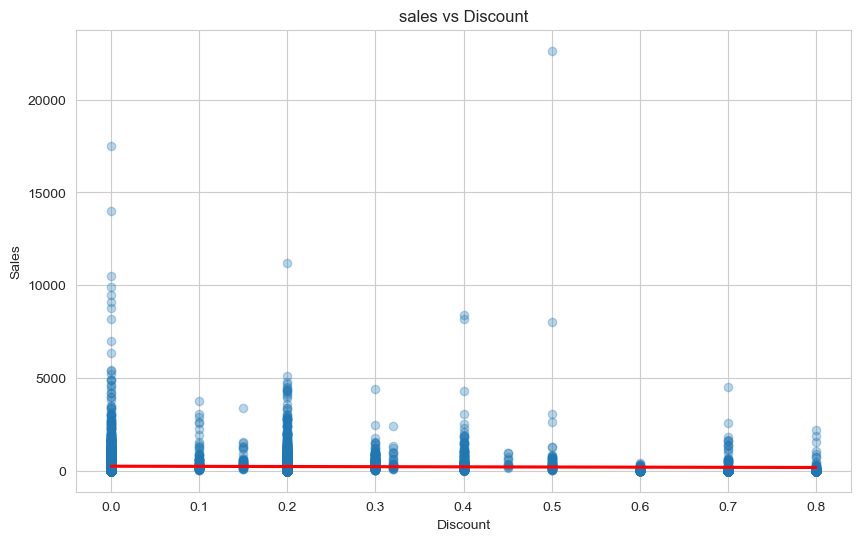

In [143]:
plt.figure(figsize=(10,6))
sns.regplot(data=numeric_columns, x="Discount", y="Sales", scatter_kws = {'alpha':0.3}, line_kws = {"color": "red"})
plt.title("sales vs Discount")
plt.xlabel("Discount")
plt.ylabel("Sales")
plt.show()

### Discounts are not effectively driving sales in this dataset. This suggests that customer purchasing behavior may not be highly price-sensitive, or discounts are not applied strategically to high demand products.

In [84]:
corr_bw_sales_profit = numeric_columns["Sales"].corr(numeric_columns["Profit"])

In [85]:
print(f"The Correlation between Sales and Profit is: {corr_bw_sales_profit:.4f}")

The Correlation between Sales and Profit is: 0.4791


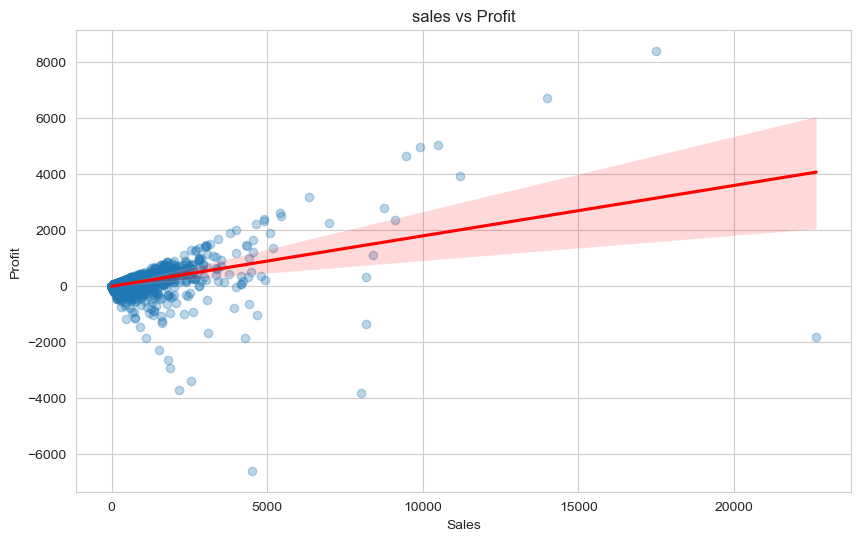

In [144]:
plt.figure(figsize=(10,6))
sns.regplot(data=numeric_columns, x="Sales", y="Profit", scatter_kws = {'alpha':0.3}, line_kws = {"color": "red"})
plt.title("sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.show()

### There is a moderate positive relationship between sales and profit, indicating that increased sales generally lead to higher profits. However, the relationship is not strong, suggesting that other factors—such as discounting and cost structure also significantly influence profitability

In [87]:
corr_bw_quantity_profit = numeric_columns["Quantity"].corr(numeric_columns["Profit"])

In [88]:
print(f"The Correlation between Quantity and Profit is: {corr_bw_quantity_profit:.4f}")

The Correlation between Quantity and Profit is: 0.0662


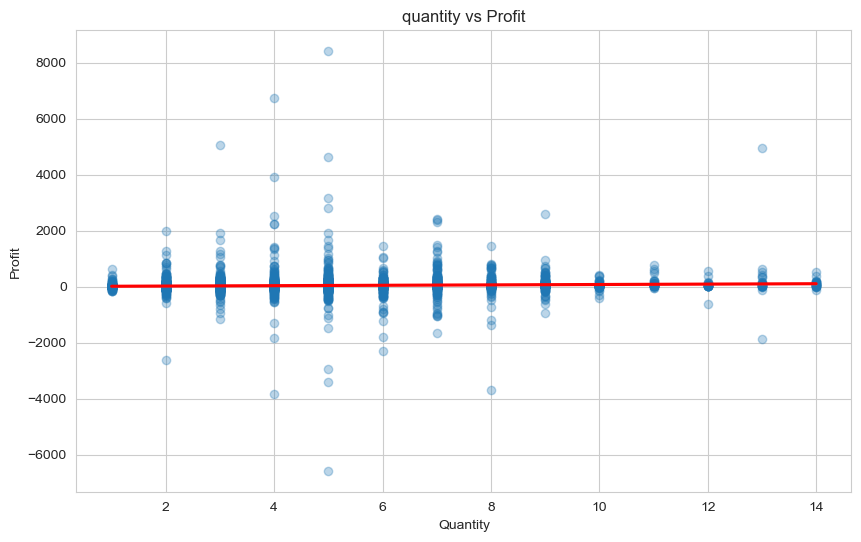

In [145]:
plt.figure(figsize=(10,6))
sns.regplot(data=numeric_columns, x="Quantity", y="Profit", scatter_kws = {'alpha':0.3}, line_kws = {"color": "red"})
plt.title("quantity vs Profit")
plt.xlabel("Quantity")
plt.ylabel("Profit")
plt.show()

In [90]:
corr_bw_quantity_discount = numeric_columns["Quantity"].corr(numeric_columns["Discount"])

In [91]:
print(f"The Correlation between Quantity and Discount is: {corr_bw_quantity_discount:.4f}")

The Correlation between Quantity and Discount is: 0.0087


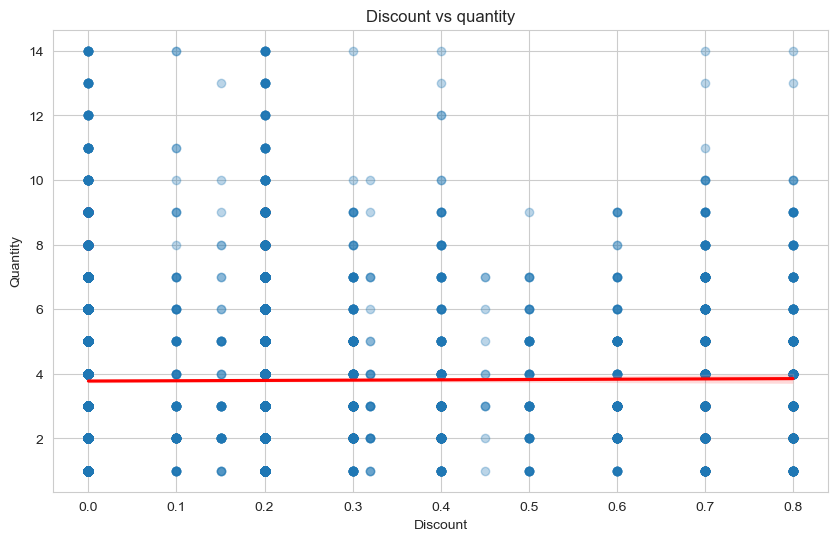

In [146]:
plt.figure(figsize=(10,6))
sns.regplot(data=numeric_columns, x="Discount", y="Quantity", scatter_kws = {'alpha':0.3}, line_kws = {"color": "red"})
plt.title("Discount vs quantity")
plt.xlabel("Discount")
plt.ylabel("Quantity")
plt.show()

### The correlation between quantity and discount is 0.008, indicating no significant relationship. This suggests that offering discounts does not effectively increase the number of items sold, implying that customer demand may be influenced more by product necessity or preference rather than pricing incentives.

# Discount Sensitivity Analysis

In [93]:
df["Discount_bin"] = pd.cut(
    df["Discount"],
    bins=[-0.01, 0.1, 0.2, 0.3, 0.5, 1],
    labels=["0-10%", "10-20%", "20-30%", "30-50%", "50%+"]
)

In [120]:
discount_analysis = df.groupby("Discount_bin",observed=False)[["Quantity", "Sales", "Profit"]].mean()

In [121]:
print(discount_analysis)

              Quantity       Sales      Profit
Discount_bin                                  
0-10%         3.811309  233.896110   67.583197
10-20%        3.737382  213.782312   24.757247
20-30%        3.747788  455.510102  -45.828401
30-50%        3.796774  630.047603 -156.282991
50%+          3.913450   75.117163  -89.535455


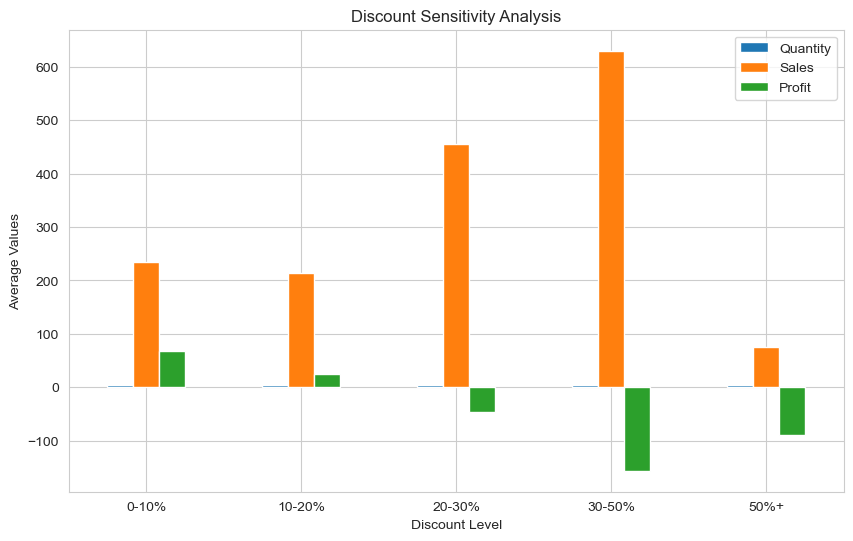

In [147]:
discount_analysis.plot(kind="bar", figsize=(10,6))
plt.title("Discount Sensitivity Analysis")
plt.ylabel("Average Values")
plt.xlabel("Discount Level")
plt.xticks(rotation=0)
plt.show()

In [101]:
print("Quantity by Discount Level:")
print(discount_analysis["Quantity"])

Quantity by Discount Level:
Discount_bin
0-10%     3.811309
10-20%    3.737382
20-30%    3.747788
30-50%    3.796774
50%+      3.913450
Name: Quantity, dtype: float64


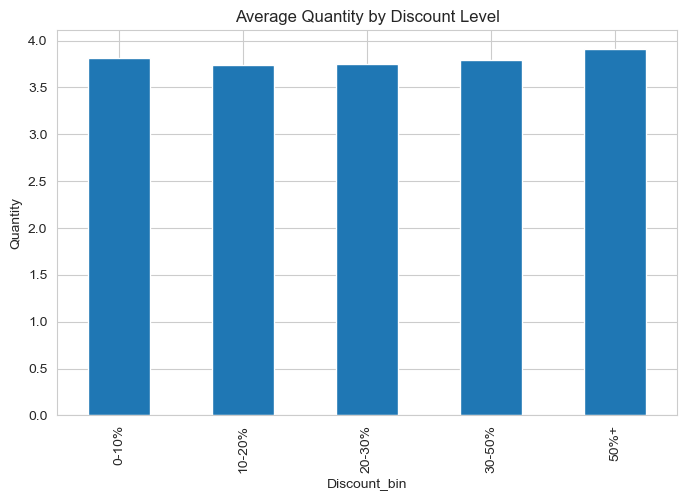

In [148]:
discount_analysis["Quantity"].plot(kind="bar", figsize=(8,5))
plt.title("Average Quantity by Discount Level")
plt.ylabel("Quantity")
plt.show()

In [103]:
print("Sales by Discount Level:")
print(discount_analysis["Sales"])

Sales by Discount Level:
Discount_bin
0-10%     233.896110
10-20%    213.782312
20-30%    455.510102
30-50%    630.047603
50%+       75.117163
Name: Sales, dtype: float64


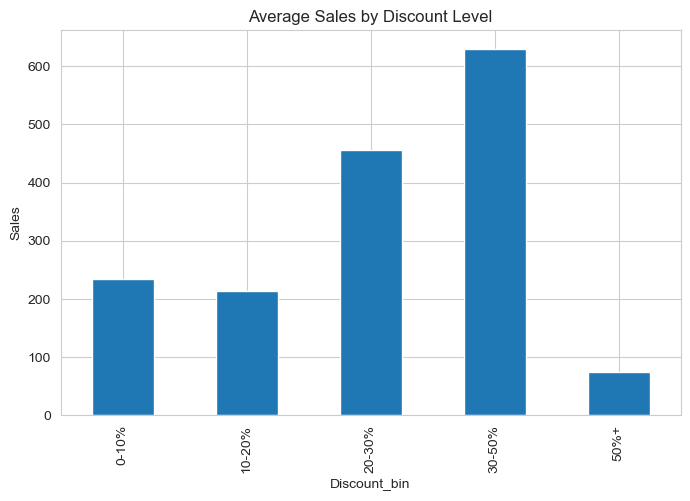

In [149]:
discount_analysis["Sales"].plot(kind="bar", figsize=(8,5))
plt.title("Average Sales by Discount Level")
plt.ylabel("Sales")
plt.show()

In [105]:
print("Profit by Discount Level:")
print(discount_analysis["Profit"])

Profit by Discount Level:
Discount_bin
0-10%      67.583197
10-20%     24.757247
20-30%    -45.828401
30-50%   -156.282991
50%+      -89.535455
Name: Profit, dtype: float64


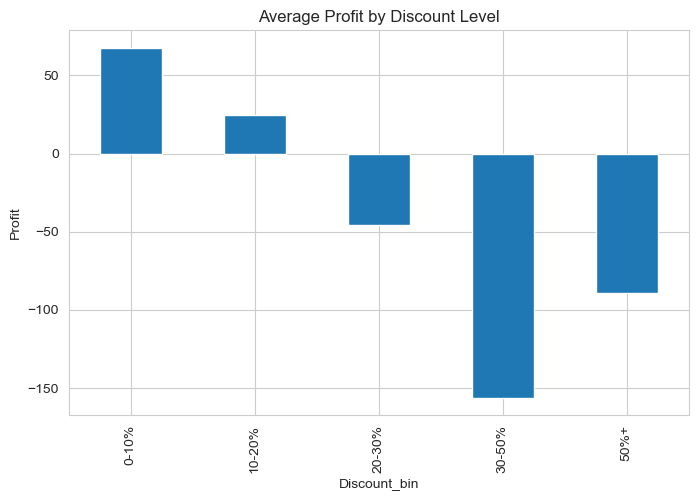

In [150]:
discount_analysis["Profit"].plot(kind="bar", figsize=(8,5))
plt.title("Average Profit by Discount Level")
plt.ylabel("Profit")
plt.show()

In [108]:
loss_bins = discount_analysis[discount_analysis["Profit"] < 0]
print("Loss-making discount ranges:")
print(loss_bins)

Loss-making discount ranges:
              Quantity       Sales      Profit
Discount_bin                                  
20-30%        3.747788  455.510102  -45.828401
30-50%        3.796774  630.047603 -156.282991
50%+          3.913450   75.117163  -89.535455


### The analysis reveals that profit remains positive up to the X–Y% discount range, beyond which it turns negative. This indicates a clear profit threshold (profit cliff), suggesting that discounts beyond this level lead to unsustainable losses.

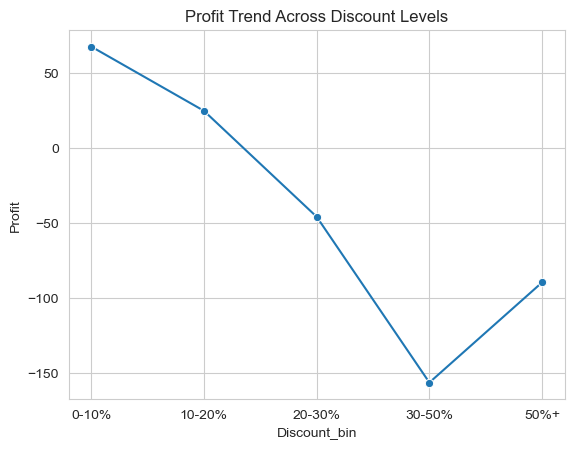

In [151]:
sns.lineplot(data=discount_analysis.reset_index(), x="Discount_bin", y="Profit", marker="o")
plt.title("Profit Trend Across Discount Levels")
plt.show()

In [132]:
category_analysis = df.groupby(["Category", "Discount_bin"], observed=False)[["Profit"]].mean().unstack()

In [133]:
print(category_analysis)

                     Profit                                              
Discount_bin          0-10%     10-20%     20-30%      30-50%        50%+
Category                                                                 
Furniture         71.651176  11.521650 -48.340534 -203.250566  -64.311076
Office Supplies   41.929372  17.299978        NaN         NaN  -69.416643
Technology       159.497610  54.735560  65.207900 -101.432746 -851.274743


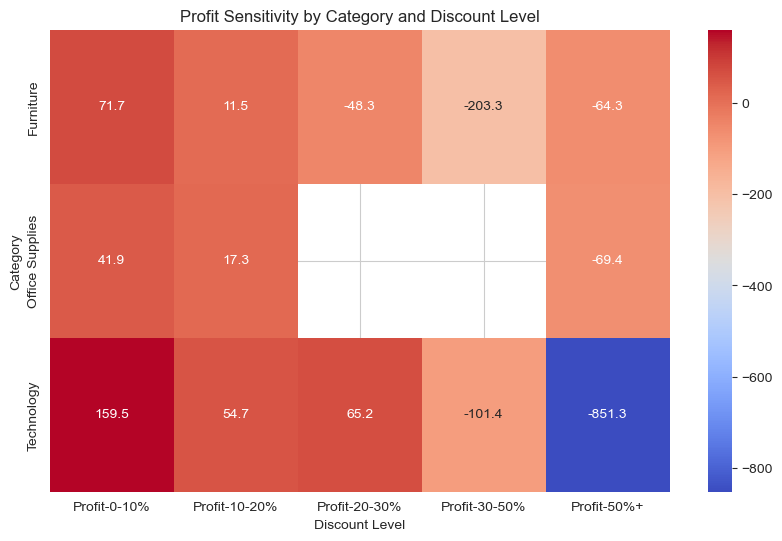

In [152]:
plt.figure(figsize=(10,6))
sns.heatmap(category_analysis, annot=True, cmap="coolwarm", fmt=".1f")
plt.title("Profit Sensitivity by Category and Discount Level")
plt.xlabel("Discount Level")
plt.ylabel("Category")
plt.show()

# Business Recommendations

# 1. Optimize Discount Strategy

## Discounts beyond a certain threshold significantly reduce profitability without meaningfully increasing sales or quantity.

### Recommendation:

- #### Maintain discounts primarily within the 0–10% range, as this yields the highest profitability. Discounts beyond 20% should be used cautiously, as they significantly reduce profit and may lead to losses.
- #### Avoid high discount ranges where profit turns negative
- #### Implement controlled discounting instead of aggressive price cuts

------------------------------------------------------------------------------------------------------------------------------------------------------

# 2. Shift Focus from Discounts to Value

## Analysis shows discounts do not strongly influence sales or quantity.

### Recommendation:

#### Invest in:
- ##### Product quality
    - ###### Customer experience
    - ###### Branding
- ##### Use discounts strategically, not as the primary sales driver

------------------------------------------------------------------------------------------------------------------------------------------------------

# 3. Category-Specific Discounting

## Different categories respond differently to discounts. 

### While Technology products yield the highest profits at lower discount levels, they also exhibit the steepest losses at extreme discounts, indicating that aggressive discounting is particularly harmful for high-margin categories.
### Recommendation:

- #### Apply low discounts to sensitive categories (e.g. Furniture - Drops to negative much earlier)
- #### Allow moderate discounts for stable categories
- #### Avoid “one-size-fits-all” discount policies

------------------------------------------------------------------------------------------------------------------------------------------------------

# 4. Data-Driven Pricing Strategy

## Correlation and sensitivity analysis show pricing inefficiencies.

### Recommendation:
- #### Use historical data to:
    - ##### Identify optimal price points
    - ##### Predict profit impact before applying discounts
- #### Move toward dynamic pricing strategies

------------------------------------------------------------------------------------------------------------------------------------------------------

# 5. Targeted Promotions Instead of Broad Discounts

## Discounts are not uniformly effective across all products.

### Recommendation:

- #### Apply discounts:
    - ##### On slow-moving inventory
    - ##### In specific regions or segments
- #### Avoid blanket discounts across all products

------------------------------------------------------------------------------------------------------------------------------------------------------

# CONCLUSION

- ## The analysis identifies a clear profit cliff, where profitability starts declining sharply beyond the 10–20% discount range and turns negative at higher discount levels.
- ## The analysis indicates that current discounting strategies are inefficient, as they reduce profitability without significantly improving sales or quantity. A shift toward controlled, data-driven, and category specific pricing strategies is essential to ensure sustainable business growth and improved profit margins.